# ***Assignment #1 - Performance Benchmarking of Cryptographic Mechanisms***

#### **Bibliotecas Utilizadas**

In [115]:
import timeit
import statistics
import matplotlib.pyplot as plt
import numpy as np
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.backends import default_backend
import hashlib
from os import urandom
import os

### **A. Gerar ficheiros de texto random com tamanhos específicos**

As funções abaixo geram ficheiros com os seguintes tamanhos:<br>

    •Para AES (em bytes): 8, 64, 512, 4096, 32768, 262144, 2097152
    •Para SHA (em bytes): 8, 64, 512, 4096, 32768, 262144, 2097152
    •Para RSA (em bytes): 2, 4, 8, 16, 32, 64, 128

In [116]:


# Generates a random binary file of a given size
def generate_random_text_file(filepath, size):
    with open(filepath, "wb") as file:
        file.write(os.urandom(size))  

# Generates AES test files
def generate_files_aes():
    aes_sizes = [8, 64, 512, 4096, 32768, 262144, 2097152]
    os.makedirs("AES", exist_ok=True)
    file_paths = []

    for size in aes_sizes:
        file_path = f'AES/AES_{size}bytes.txt'
        generate_random_text_file(file_path, size)
        file_paths.append(file_path)

    return file_paths, aes_sizes

# Generates RSA test files
def generate_files_rsa():
    rsa_sizes = [2, 4, 8, 16, 32, 64, 128]
    os.makedirs("RSA", exist_ok=True)
    file_paths = []

    for size in rsa_sizes:
        file_path = f"RSA/RSA_{size}bytes.txt"
        generate_random_text_file(file_path, size)
        file_paths.append(file_path)

    return file_paths, rsa_sizes

# Generates SHA test files
def generate_files_sha():
    sha_sizes = [8, 64, 512, 4096, 32768, 262144, 2097152]
    os.makedirs("SHA", exist_ok=True)
    file_paths = []

    for size in sha_sizes:
        file_path = f"SHA/SHA_{size}bytes.txt"
        generate_random_text_file(file_path, size)
        file_paths.append(file_path)

    return file_paths, sha_sizes


### **B. Encriptação e desencriptação em AES**

Abaixo apresentaremos as funções de encriptação, desencriptação, medição de tempo e geração da chave e do IV. A chave terá 256 bits. Para a medição do tempo será utilizado o módulo timeit do python.


In [117]:
# AES Encryption function
def encrypt_aes(data, key, iv):
    backend = default_backend()
    cipher = Cipher(algorithms.AES(key), modes.CFB(iv), backend=backend)
    encryptor = cipher.encryptor()
    return encryptor.update(data) + encryptor.finalize()

# AES Decryption function
def decrypt_aes(ciphertext, key, iv):
    backend = default_backend()
    cipher = Cipher(algorithms.AES(key), modes.CFB(iv), backend=backend)
    decryptor = cipher.decryptor()
    return decryptor.update(ciphertext) + decryptor.finalize()


# Function to measure only encryption/decryption execution times (statistically significant)
def measure_multiple_times(func, args, runs):
    times = []
    for _ in range(runs):
        start = timeit.default_timer()
        _ = func(*args)
        end = timeit.default_timer()
        times.append((end - start) * 1e6)  # microseconds
    return statistics.mean(times), statistics.stdev(times), times

# Generate AES key and IV
def generate_key_iv():
    return urandom(32), urandom(16) # AES key size is 256 bits (32 bytes)



#### **I. Encriptação e desencriptação de ficheiros em AES**

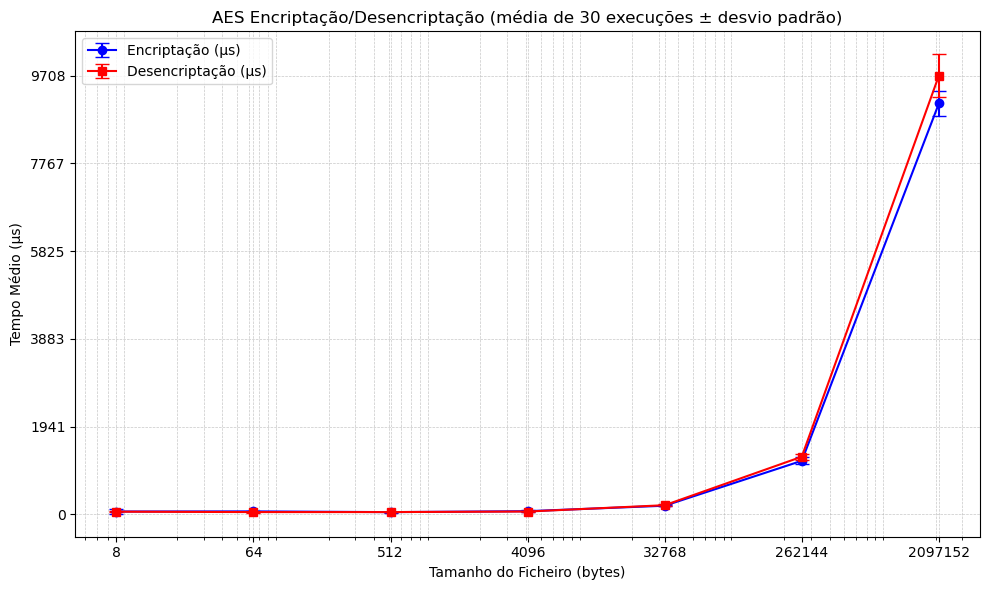

In [131]:


# Inicializar chave e IV
key, iv = generate_key_iv()  # Supondo que esta função já está definida

# Gerar arquivos de teste (já definida)
aes_files, aes_sizes = generate_files_aes()  # Certifique-se de que esta função já está definida

# Listas para armazenar médias e desvios padrão
enc_avg_list = []
enc_std_list = []
dec_avg_list = []
dec_std_list = []

# Medir para cada arquivo
for file_path in aes_files:
    with open(file_path, "rb") as file:
        data = file.read()

    # Medir tempos de encriptação (30 execuções)
    enc_avg, enc_std, enc_runs = measure_multiple_times(encrypt_aes, (data, key, iv), 30)
    ciphertext = encrypt_aes(data, key, iv)  # Necessário para gerar o que será desencriptado

    # Medir tempos de desencriptação (30 execuções)
    dec_avg, dec_std, dec_runs = measure_multiple_times(decrypt_aes, (ciphertext, key, iv), 30)

    # Guardar médias e desvios padrão
    enc_avg_list.append(enc_avg)
    enc_std_list.append(enc_std)
    dec_avg_list.append(dec_avg)
    dec_std_list.append(dec_std)

# Gráfico com barras de erro
plt.figure(figsize=(10, 6))

# Encriptação com desvio padrão
plt.errorbar(aes_sizes, enc_avg_list, yerr=enc_std_list, fmt='o-', color='blue', label='Encriptação (µs)', capsize=5)

# Desencriptação com desvio padrão
plt.errorbar(aes_sizes, dec_avg_list, yerr=dec_std_list, fmt='s-', color='red', label='Desencriptação (µs)', capsize=5)

# Escala logarítmica para tamanhos
plt.xscale('log')
plt.xticks(aes_sizes, labels=[str(size) for size in aes_sizes])
yticks = np.linspace(0, max(enc_avg_list + dec_avg_list), num=6)
plt.yticks(yticks, labels=[f"{int(y)}" for y in yticks])

# Configurações do gráfico
plt.xlabel('Tamanho do Ficheiro (bytes)')
plt.ylabel('Tempo Médio (µs)')
plt.title("AES Encriptação/Desencriptação (média de 30 execuções ± desvio padrão)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


##### **Análise:**


O gráfico apresenta os tempos de execução do algoritmo AES no modo CFB (Cipher Feedback) para arquivos de diversos tamanhos. O AES divide os dados em blocos e utilizando uma chave criptográfica com um vetor de inicialização (IV) para transformar o texto original em texto cifrado.

No processo de encriptação, o algoritmo começa por aplicar a chave e o IV ao primeiro bloco de dados, gerando o primeiro bloco cifrado. Em seguida, esse bloco cifrado é utilizado como entrada para encriptar o próximo bloco de texto original, repetindo esse procedimento até que todos os dados sejam processados.
Já na desencriptação, como todos os blocos cifrados estão disponíveis desde o início, o algoritmo não precisa de aguardar a conclusão do bloco anterior para iniciar o processamento. Esta característica explica o porquoê dos tempos de encriptação e desencriptação serem tão próximos, com apenas uma ligeira diferença entre eles.

Além disso, observa-se que o tempo de execução do AES aumenta proporcionalmente ao tamanho do arquivo, uma vez que precisam de ser processados mais blocos. Relativamente ao desvio padrão, verificamos que este nunca tem um valor muito elevado, portanto podemos concluir que os valores das médias são confiáveis.

#### **II. Múltiplas encriptações e desencriptações dos mesmos ficheiros em AES**

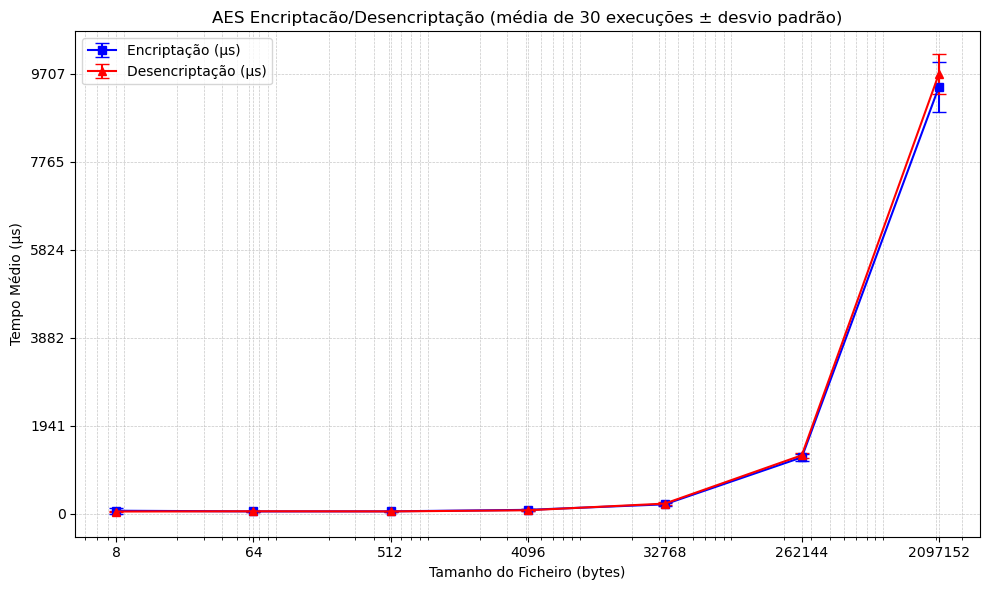

In [132]:


# Gerar chave e IV (assumido que a função está definida)
key, iv = generate_key_iv()

# Gerar arquivos de teste (assumido que a função já está definida)
aes_files, aes_sizes = generate_files_aes()

# Listas para armazenar resultados de tempo
enc_avg_list = []
enc_std_list = []
dec_avg_list = []
dec_std_list = []

# Loop de teste para cada arquivo
for file_path in aes_files:
    with open(file_path, "rb") as file:
        data = file.read()

    # Medição da encriptação (com 30 execuções para cada arquivo)
    enc_avg, enc_std, _ = measure_multiple_times(encrypt_aes, (data, key, iv), 30)

    # Encriptar uma vez para obter o ciphertext necessário para desencriptação
    ciphertext = encrypt_aes(data, key, iv)

    # Medição da desencriptação (com 30 execuções para cada arquivo)
    dec_avg, dec_std, _ = measure_multiple_times(decrypt_aes, (ciphertext, key, iv), 30)

    # Armazenar resultados de média e desvio padrão
    enc_avg_list.append(enc_avg)
    enc_std_list.append(enc_std)
    dec_avg_list.append(dec_avg)
    dec_std_list.append(dec_std)

# Criar gráfico para visualização dos tempos
plt.figure(figsize=(10, 6))

# Plotar os tempos médios de encriptação com barras de erro
plt.errorbar(aes_sizes, enc_avg_list, yerr=enc_std_list, fmt='s-', capsize=5, label='Encriptação (µs)', color='blue')

# Plotar os tempos médios de desencriptação com barras de erro
plt.errorbar(aes_sizes, dec_avg_list, yerr=dec_std_list, fmt='^-', capsize=5, label='Desencriptação (µs)', color='red')

# Definir escala logarítmica para o eixo X (tamanho dos arquivos)
plt.xscale('log')
plt.xticks(aes_sizes, labels=[str(size) for size in aes_sizes])

# Ajustar ticks do eixo Y para os tempos (linear)
yticks = np.linspace(0, max(enc_avg_list + dec_avg_list), num=6)
plt.yticks(yticks, labels=[f"{int(y)}" for y in yticks])

# Adicionar rótulos e título
plt.xlabel('Tamanho do Ficheiro (bytes)')
plt.ylabel('Tempo Médio (µs)')
plt.title('AES Encriptacão/Desencriptação (média de 30 execuções ± desvio padrão)')

# Estilo e ajustes no gráfico
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()

# Exibir gráfico
plt.show()


##### **Análise:**

O gráfico apresenta os tempos médios de execução do algoritmo AES no modo CFB ao processar repetidamente o mesmo arquivo(300 iterações). Os resultados demonstram que o tempo médio de criptografia e descriptografia apresenta um comportamento semelhante ao da secção B1, onde o arquivo é processo um número menor de vezes.
O que indica que o desempenho do AES não varia significativamente com o aumento do número de iterações. O comportamento observado é consistente com os resultados apresentados anteriormente, reforçando que o algoritmo mantém sua eficiência e previsibilidade independentemente da quantidade de execuções consecutivas.
Em relação ao desvio padrão, verificamos que este nunca apresenta um valor muito elevado, assim podemos concluir que estes valores são confiáveis.


#### **III. Encriptação e desencriptação de múltiplos ficheiros gerados aleatoriamente para cada tamanho fixo** 

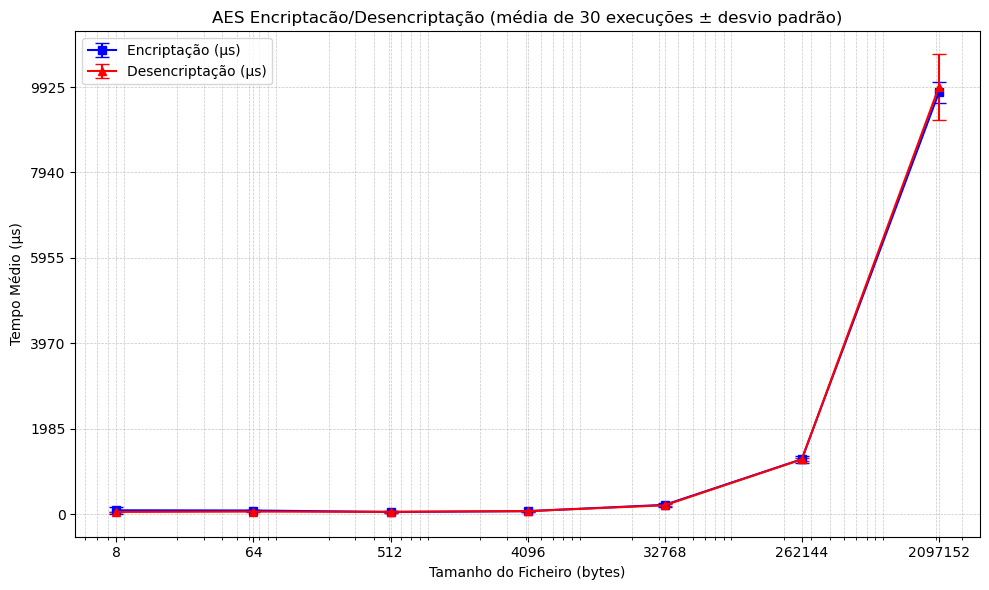

In [133]:
encryption_avg_times = []
decryption_avg_times = []
encryption_std_times = []
decryption_std_times = []

key, iv = generate_key_iv()
_, aes_sizes = generate_files_aes()

for size in aes_sizes:
    data = os.urandom(size)
    enc_avg, enc_std, _ = measure_multiple_times(encrypt_aes, (data, key, iv), 10)
    ciphertext = encrypt_aes(data, key, iv)
    dec_avg, dec_std, _ = measure_multiple_times(decrypt_aes, (ciphertext, key, iv), 10)

    encryption_avg_times.append(enc_avg)
    decryption_avg_times.append(dec_avg)
    encryption_std_times.append(enc_std)
    decryption_std_times.append(dec_std)

# Gráfico
plt.figure(figsize=(10, 6))
plt.errorbar(aes_sizes, encryption_avg_times, yerr=encryption_std_times, fmt='s-', color='blue', label='Encriptação (µs)', capsize=5)
plt.errorbar(aes_sizes, decryption_avg_times, yerr=decryption_std_times, fmt='^-', color='red', label='Desencriptação (µs)', capsize=5)

plt.xscale('log')
plt.xticks(aes_sizes, labels=[str(size) for size in aes_sizes])
yticks = np.linspace(0, max(encryption_avg_times + decryption_avg_times), num=6)
plt.yticks(yticks, labels=[f"{int(y)}" for y in yticks])

plt.xlabel('Tamanho do Ficheiro (bytes)')
plt.ylabel('Tempo Médio (µs)')
plt.title('AES Encriptacão/Desencriptação (média de 30 execuções ± desvio padrão)')
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


##### **Análise:**

O gráfico apresenta o tempo médio necessário para a execução do algoritmo AES em sete ficheiros distintos para cada tamanho especificado.
Observa-se que o tempo médio para encriptar/dencriptar os sete ficheiros não difere significativamente do tempo requerido para processar apenas um ficheiro. O comportamento do algoritmo AES mantém-se consistente, tal como descrito na secção BI. Deste modo, podemos concluir que o desempenho do AES não é influenciado pelo conteúdo dos ficheiros. 
Relativamente ao desvio padrão, verificamos que este não apresenta um valor muito elevado, portanto podemos assumir que este valores são confiáveis.



### **C. Encriptação e desencriptação em RSA**

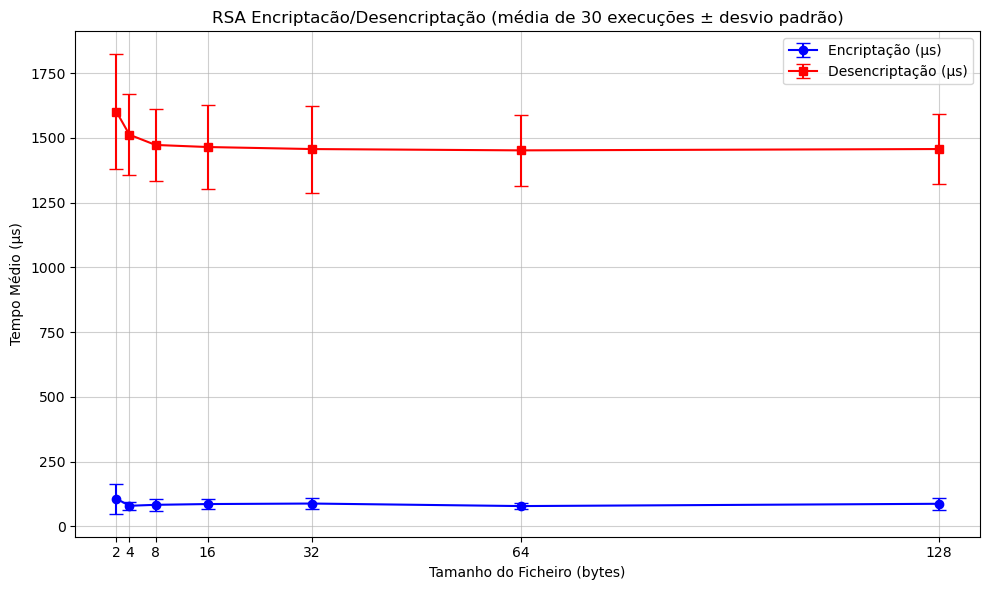

In [121]:


# Gerar chave RSA
def generate_rsa_key():
    return rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048,
        backend=default_backend()
    )

# Medir tempos de encriptação e desencriptação em várias execuções
def measure_rsa_times(data, public_key, private_key, runs=30):
    encryption_times = []
    decryption_times = []

    for _ in range(runs):
        # Encriptação
        start_enc = timeit.default_timer()
        ciphertext = public_key.encrypt(
            data,
            padding.OAEP(
                mgf=padding.MGF1(algorithm=hashes.SHA256()),
                algorithm=hashes.SHA256(),
                label=None
            )
        )
        end_enc = timeit.default_timer()
        encryption_times.append((end_enc - start_enc) * 1e6)

        # Desencriptação
        start_dec = timeit.default_timer()
        plaintext = private_key.decrypt(
            ciphertext,
            padding.OAEP(
                mgf=padding.MGF1(algorithm=hashes.SHA256()),
                algorithm=hashes.SHA256(),
                label=None
            )
        )
        end_dec = timeit.default_timer()
        decryption_times.append((end_dec - start_dec) * 1e6)

    # Calcular média e desvio padrão
    enc_avg = statistics.mean(encryption_times)
    enc_std = statistics.stdev(encryption_times)
    dec_avg = statistics.mean(decryption_times)
    dec_std = statistics.stdev(decryption_times)

    return enc_avg, enc_std, dec_avg, dec_std

# Gerar chaves
private_key = generate_rsa_key()
public_key = private_key.public_key()

# Gerar ficheiros de teste
rsa_files, rsa_sizes = generate_files_rsa()

# Listas para tempos e desvios padrão
enc_avg_list = []
enc_std_list = []
dec_avg_list = []
dec_std_list = []
filtered_sizes = []

# Medir tempos para cada ficheiro
for file_path, size in zip(rsa_files, rsa_sizes):
    with open(file_path, "rb") as f:
        data = f.read()

    if len(data) > 190:  # RSA (2048-bit) limite prático com OAEP + SHA-256
        print(f"Skipping {file_path} - tamanho excede limite RSA")
        continue

    enc_avg, enc_std, dec_avg, dec_std = measure_rsa_times(data, public_key, private_key)

    enc_avg_list.append(enc_avg)
    enc_std_list.append(enc_std)
    dec_avg_list.append(dec_avg)
    dec_std_list.append(dec_std)
    filtered_sizes.append(size)

# Gráfico com barras de erro
plt.figure(figsize=(10, 6))

# Encriptação
plt.errorbar(filtered_sizes, enc_avg_list, yerr=enc_std_list, fmt='o-', color='blue', label='Encriptação (µs)', capsize=5)

# Desencriptação
plt.errorbar(filtered_sizes, dec_avg_list, yerr=dec_std_list, fmt='s-', color='red', label='Desencriptação (µs)', capsize=5)

# Eixos e título
plt.xlabel('Tamanho do Ficheiro (bytes)')
plt.ylabel('Tempo Médio (µs)')
plt.title("RSA Encriptacão/Desencriptação (média de 30 execuções ± desvio padrão)")
plt.xticks(filtered_sizes)
plt.grid(True, linestyle='-', alpha=0.6)
plt.legend()
plt.tight_layout()

# Mostrar gráfico
plt.show()


##### **Análise:**


Nos tamanhos de arquivo mais pequenos, à medida que o tamanho do ficheiro aumenta, verifica-se uma redução considerável do tempo de execução do RSA, o que se deve ao facto deste incluir o tempo que o programa leva para processar os dados inicialmente. O CPU demora a processar os ficheiros, e o tempo de acesso à memória também é relevante para explicar estes resultados.
No gráfico, há uma diferença significativa entre os tempos de encriptação e desencriptação, sendo que o tempo de desencriptação é visivelmente superior ao tempo de encriptação (explicado abaixo), embora o desvio padrão seja relativamente superior nos valores da desencriptação. Em contrapartida, é possível afirmar que o tamanho do ficheiro não afeta o comportamento do RSA em ambos os processos.
O algoritmo RSA é um método de encriptação assimétrica que se baseia em exponenciação modular e utiliza um par de chaves (pública/privada).
Na encriptação, o remetente usa a chave pública do destinatário para gerar o texto cifrado, o cálculo envolve elevar o texto original ao expoente público e o expoente é pequeno e as operações aritméticas são simples.
Na desencriptação, o destinatário usa a sua chave privada para recuperar o texto original, o cálculo envolve elevar o texto cifrado ao expoente privado, que é muito maior que o expoente público.


Assim, conclui-se que o RSA mantém um desempenho consistente independentemente do tamanho do ficheiro. A diferença de velocidade entre encriptação e desencriptação deve-se à natureza assimétrica do algoritmo, onde a desencriptação exige cálculos mais complexos. O pico inicial em ficheiros pequenos está relacionado com o overhead de processamento inicial e acesso à memória.


### **D. Medição de tempo para a geração do SHA-256 hash**

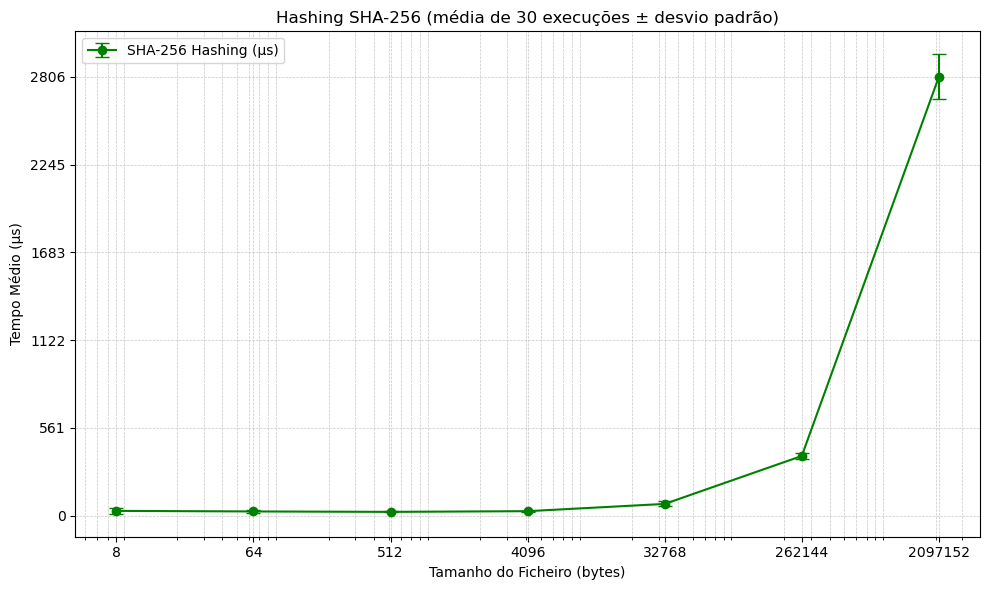

In [123]:
# Função para calcular hash SHA-256 (já definida)
def calculate_sha256_hash(file_path):
    with open(file_path, 'rb') as f:
        data = f.read()
    return hashlib.sha256(data).hexdigest()

# Função adaptada para usar measure_multiple_times com apenas o hash puro
def measure_sha_hash_time(file_path, runs=30):
    def hash_only():
        return calculate_sha256_hash(file_path)
    
    # Usar a função que mede tempos várias vezes
    return measure_multiple_times(lambda: hash_only(), (), runs)

# Gerar os ficheiros de teste (função já definida anteriormente)
sha_files, sha_sizes = generate_files_sha()

# Medir tempos de hashing
sha_hash_avg_times = []
sha_hash_std_times = []

for file in sha_files:
    avg_time, std_time, _ = measure_sha_hash_time(file, runs=30)
    sha_hash_avg_times.append(avg_time)
    sha_hash_std_times.append(std_time)

# Plot
plt.figure(figsize=(10, 6))

# Gráfico com barras de erro
plt.errorbar(sha_sizes, sha_hash_avg_times, yerr=sha_hash_std_times, fmt='o-', color='green',
             capsize=5, label='SHA-256 Hashing (µs)')

# Escala logarítmica para o eixo X
plt.xscale('log')
plt.xticks(sha_sizes, labels=[f"{size}" for size in sha_sizes])

# Escala dinâmica do eixo Y
yticks = np.linspace(0, max(sha_hash_avg_times), num=6)
plt.yticks(yticks, labels=[f"{int(y)}" for y in yticks])

# Rótulos e título
plt.xlabel('Tamanho do Ficheiro (bytes)')
plt.ylabel('Tempo Médio (µs)')
plt.title('Hashing SHA-256 (média de 30 execuções ± desvio padrão)')

# Estilo
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


##### **Análise:**

O gráfico apresenta os tempos de geração de hash para ficheiros com diferentes tamanhos. Nos primeiros tamanhos de ficheiro, observa-se um ligeiro aumento devido ao tempo que o programa necessita para processar inicialmente os dados. O tempo de processamento por parte da CPU, bem como o tempo de acesso à memória, são fatores relevantes que ajudam a explicar estes resultados.


Através da linha representada no gráfico, é possível concluir que o tempo de geração do hash tende a aumentar à medida que cresce o tamanho do ficheiro  e que o desvio padrão é praticamente nulo, embora aumente no ficheiro de maior dimensão, o que nos permite considerar os dados viáveis.




### **E. Comparações**

#### **Encriptação AES vs encriptação RSA**

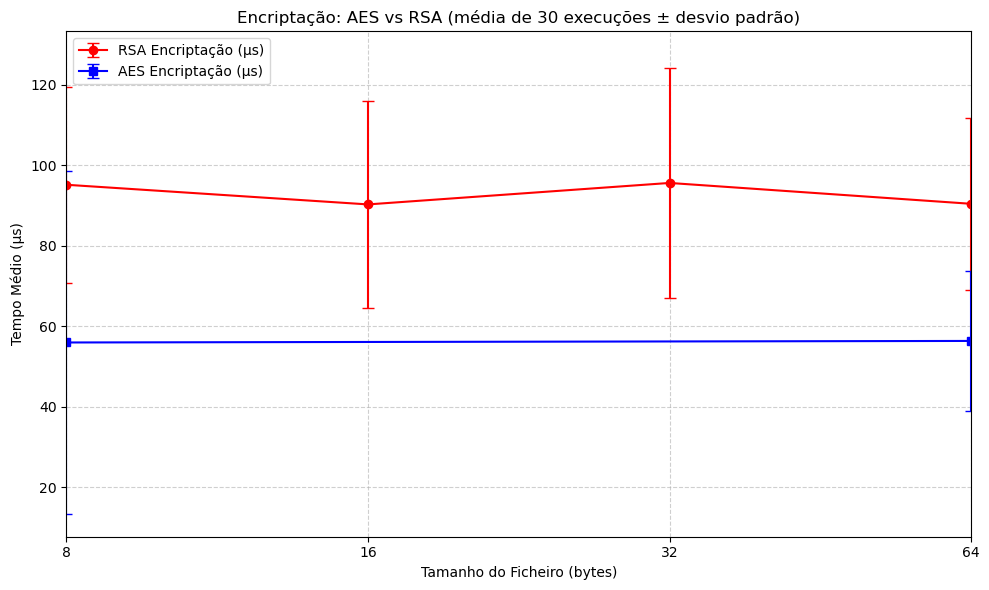

In [140]:
# Gerar ficheiros e chaves (com tamanhos até 128 bytes)
aes_files, aes_sizes = generate_files_aes()
rsa_files, rsa_sizes = generate_files_rsa()
aes_key, aes_iv = generate_key_iv()
rsa_private = generate_rsa_key()
rsa_public = rsa_private.public_key()

# Limitar os tamanhos dos ficheiros para ≤128 bytes (8 a 128 bytes)
aes_sizes = [size for size in aes_sizes if size <= 128]
rsa_sizes = [size for size in rsa_sizes if size <= 128]

# Regerar os ficheiros com os tamanhos limitados
aes_files = [f'AES/AES_{size}bytes.txt' for size in aes_sizes]
rsa_files = [f'RSA/RSA_{size}bytes.txt' for size in rsa_sizes]

# Inicializar listas para resultados de encriptação
encryption_times_aes_avg, encryption_times_aes_std = [], []
encryption_times_rsa_avg, encryption_times_rsa_std = [], []

# AES – medir tempos de encriptação
for file in aes_files:
    with open(file, 'rb') as f:
        data = f.read()

    enc_avg, enc_std, _ = measure_multiple_times(encrypt_aes, (data, aes_key, aes_iv), runs=30)
    
    encryption_times_aes_avg.append(enc_avg)
    encryption_times_aes_std.append(enc_std)

# RSA – medir tempos de encriptação
for file in rsa_files:
    with open(file, 'rb') as f:
        data = f.read()

    # Ajuste aqui para desempacotar todos os 4 valores e pegar apenas os tempos de encriptação
    enc_avg, enc_std, _, _ = measure_rsa_times(data, rsa_public, rsa_private, runs=30)

    encryption_times_rsa_avg.append(enc_avg)
    encryption_times_rsa_std.append(enc_std)

# Gráfico: ENCRIPTAÇÃO
plt.figure(figsize=(10, 6))

# Plotar tempos de encriptação RSA
plt.errorbar(rsa_sizes, encryption_times_rsa_avg, yerr=encryption_times_rsa_std, fmt='o-', color='red', capsize=4, label='RSA Encriptação (µs)')

# Plotar tempos de encriptação AES (limitado ao tamanho de RSA)
plt.errorbar(aes_sizes[:len(rsa_sizes)], encryption_times_aes_avg[:len(rsa_sizes)], yerr=encryption_times_aes_std[:len(rsa_sizes)], fmt='s-', color='blue', capsize=4, label='AES Encriptação (µs)')

# Usar escala logarítmica para o eixo x (tamanhos de ficheiros)
plt.xscale('log')

# Definir os tamanhos exatos que quer mostrar (apenas potências de 2)
exact_sizes = [8, 16, 32, 64]  # Ou use valid_sizes se quiser manter seus valores originais

# Configurar os ticks do eixo x
ax = plt.gca()
ax.set_xticks(exact_sizes)
ax.set_xticklabels([str(size) for size in exact_sizes])

# Remover os ticks menores (que criam os valores como 2×10¹)
ax.xaxis.set_minor_locator(plt.NullLocator())

# Definir rótulos e título
plt.xlabel('Tamanho do Ficheiro (bytes)')
plt.ylabel('Tempo Médio (µs)')
plt.title('Encriptação: AES vs RSA (média de 30 execuções ± desvio padrão)')

# Limitar o eixo x
plt.xlim(min(exact_sizes), max(exact_sizes))

# Adicionar grade para melhor visualização
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar legenda
plt.legend()

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()

##### **Análise**

O gráfico mostra os tempos de encriptação do AES e do RSA em vários ficheiros de diferentes tamanhos.

Podemos afirmar que o algoritmo RSA demora mais tempo a encriptar um ficheiro do que o AES, devido às diferenças nos seus processos.  Além disso, também verificamos que o desvio padrão é muito superior no processo de encriptação RSA, o que se deve  à complexidade computacional do RSA, à natureza das operações matemáticas envolvidas, à forma como os dados são processados e à implementação específica. Mesmo considerando o elevado desvio padrão do RSA, o algoritmo RSA é mais lento que o AES.

A encriptação AES envolve operações simples, como substituições, permutações e operações XOR. Sendo um método de encriptação simétrica, é geralmente mais rápido do que outros processos, pois requer menos poder computacional, tornando-o adequado para encriptar grandes volumes de dados.

A encriptação RSA é um método de encriptação assimétrica, pelo que demora mais tempo, uma vez que requer uma chave que tem de ser gerada, com um comprimento maior do que a utilizada no AES. O RSA é utilizado em situações em que a segurança é prioritária em relação ao tempo de encriptação.

Outra razão pela qual o AES reside no facto do AES ser mais rápido está na complexidade do RSA em comparação com o algoritmo AES, o que, consequentemente, torna o RSA mais seguro, pois é muito difícil alguém sem a chave privada aceder à informação. Esta diferença justifica por que o RSA é preferido em sistemas onde a segurança é crítica (ex: transações bancárias), enquanto o AES é ideal para encriptação de ficheiros ou comunicações em tempo real.


#### **Encriptação AES vs Geração hash SHA**

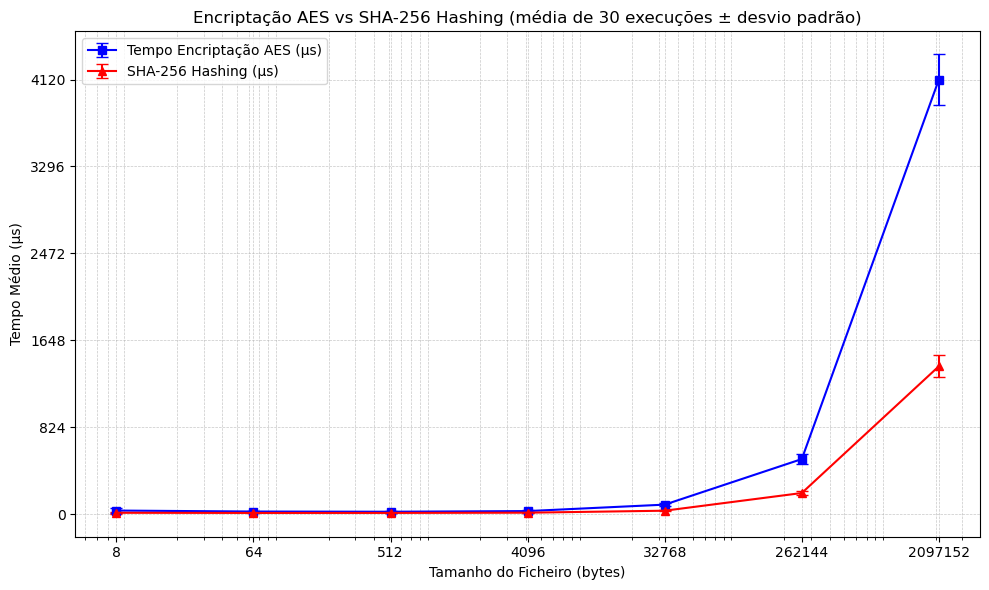

In [125]:
# Gerar ficheiros AES e SHA-256 até 128 bytes
aes_files, aes_sizes = generate_files_aes()
sha_files, sha_sizes = generate_files_sha()
aes_key, aes_iv = generate_key_iv()

# Gerar os ficheiros com tamanhos limitados até 128 bytes
aes_files = [f'AES/AES_{size}bytes.txt' for size in aes_sizes]
sha_files = [f'SHA/SHA_{size}bytes.txt' for size in sha_sizes]

# Inicializar listas para resultados de encriptação AES
encryption_times_aes_avg, encryption_times_aes_std = [], []
decryption_times_aes_avg, decryption_times_aes_std = [], []

# Inicializar listas para resultados de hashing SHA-256
sha_hash_times_avg, sha_hash_times_std = [], []

# Medir tempos para AES - encriptação
for file in aes_files:
    with open(file, 'rb') as f:
        data = f.read()
    
    # Medir o tempo de encriptação AES
    enc_avg, enc_std, _ = measure_multiple_times(encrypt_aes, (data, aes_key, aes_iv), runs=30)
    encryption_times_aes_avg.append(enc_avg)
    encryption_times_aes_std.append(enc_std)

# Medir tempos de hashing SHA-256 - de maneira estatisticamente significativa
for file in sha_files:
    # Medir o tempo de hashing SHA-256
    hash_avg, hash_std, _ = measure_multiple_times(calculate_sha256_hash, (file,), runs=30)
    sha_hash_times_avg.append(hash_avg)
    sha_hash_times_std.append(hash_std)

# Plotagem: Comparação AES vs SHA-256
plt.figure(figsize=(10, 6))

# Plotar tempos de encriptação AES
plt.errorbar(aes_sizes, encryption_times_aes_avg, yerr=encryption_times_aes_std, fmt='s-', color='blue', capsize=4, label='Tempo Encriptação AES (µs)')

# Plotar tempos de hashing SHA-256
plt.errorbar(sha_sizes, sha_hash_times_avg, yerr=sha_hash_times_std, fmt='^-', color='red', capsize=4, label='SHA-256 Hashing (µs)')

# Usar escala logarítmica para o eixo x (tamanhos de ficheiros)
plt.xscale('log')

# Customizar as marcas do eixo x para os tamanhos de ficheiros
plt.xticks(aes_sizes, labels=[f"{size}" for size in aes_sizes])

# Ajustar as marcas do eixo y com base nos dados medidos
yticks = np.linspace(0, max(encryption_times_aes_avg + sha_hash_times_avg), num=6)
plt.yticks(yticks, labels=[f"{int(y)}" for y in yticks])

# Definir os rótulos dos eixos e título
plt.xlabel('Tamanho do Ficheiro (bytes)')
plt.ylabel('Tempo Médio (µs)')
plt.title('Encriptação AES vs SHA-256 Hashing (média de 30 execuções ± desvio padrão)')

# Adicionar uma grade para facilitar a leitura
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# Adicionar legenda
plt.legend()

# Otimizar o layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()


##### **Análise:**

O gráfico apresenta o tempo de encriptação AES e a geração de resumos (hash) SHA em vários ficheiros de diferentes tamanhos. Podemos afirmar que a encriptação AES demora mais tempo do que a geração de resumos SHA-256, especialmente quando se trata de ficheiros de maior dimensão e que o desvio padrão é praticamente nulo, embora aumente ligeiramente no ficheiro de maior dimensão.

Isto acontece porque o SHA-256 é uma função de hash criptográfico que gera um valor de hash de tamanho fixo a partir dos dados de entrada e envolve um conjunto de operações relativamente simples, como operações lógicas bit a bit, rotações e adições modulares, enquanto que o AES, por outro lado, exige múltiplas rondas de processamento para cada bloco de dados, com cada ronda a incluir várias operações, como substituições, permutações e operações XOR.

Em conclusão, a geração de hashes SHA-256 é mais rápida porque realiza operações menos complexas e produz um resultado de tamanho fixo, independentemente do tamanho do ficheiro, por sua vez a encriptação AES é mais lenta devido às suas múltiplas transformações de dados em cada bloco, necessárias para garantir a segurança da cifra. Esta diferença é especialmente notória em ficheiros grandes, onde o AES tem de processar uma quantidade significativamente maior de blocos de dados.

A nível de aplicabilidade prática, o SHA-256 é ideal para verificação rápida de integridade de dados (ex: checksums) e o AES é mais adequado para encriptação segura de dados, mesmo que exija mais tempo de processamento. Apesar de SHA-256 ser mais rápido que AES, não serve como substituto para encriptação. SHA não protege contra leitura não autorizada — apenas garante que os dados não foram alterados. Estes dois métodos são frequentemente utilizados em conjunto de modo a equilibrar segurança e desempenho.


## **Conclusões:**

Neste projeto, realizámos uma análise abrangente do desempenho de algoritmos criptográficos simétricos (encriptação AES) e assimétricos (encriptação e desencriptação RSA), bem como da geração de hashes SHA-256, utilizando o módulo de criptografia do Python. Foram medidos os tempos das operações criptográficas em ficheiros de diversos tamanhos e com diferentes comprimentos de chave, com o objetivo de avaliar a sua eficiência e escalabilidade.

Encriptação e Desencriptação AES:

Observámos que os tempos de encriptação e desencriptação AES se mantiveram relativamente consistentes para diferentes tamanhos de ficheiro e diferentes números de iterações sobre o mesmo ficheiro. O AES demonstrou ser eficiente e adequado para proteger dados, especialmente em ficheiros de grande dimensão. 

Encriptação e Desencriptação RSA:

Os tempos de encriptação e desencriptação RSA aumentaram parcialmente com ficheiros maiores, como esperado devido à complexidade computacional da criptografia assimétrica. A encriptação RSA foi notavelmente mais lenta em comparação com a encriptação AES, evidenciando o compromisso entre segurança e desempenho inerente à encriptação assimétrica.

Geração de Hash SHA-256:

A geração de hashes SHA-256 apresentou um desempenho consistente independentemente do tamanho do ficheiro, uma vez que opera de forma independente deste parâmetro. Revelou-se um método rápido e fiável para gerar resumos criptográficos, essenciais para a verificação da integridade dos dados.

Conclusões na prática:

AES é a melhor escolha para encriptação eficiente de grandes volumes de dados
RSA, apesar de mais lento, é crucial para cenários que exigem segurança assimétrica
SHA-256 mantém desempenho estável, sendo ideal para verificação de integridade

Esta análise comparativa permite compreender as vantagens e limitações de cada algoritmo, facilitando a seleção da solução criptográfica mais adequada consoante os requisitos de segurança e desempenho de cada aplicação.
